In [ ]:
%matplotlib widget
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DatasetManager, DataLoader, create_windows_for_ml

# Initialize dataset manager
dataset_path = project_root / "data_set"
dm = DatasetManager(dataset_path)

# Initialize data loader 
data_loader = DataLoader(dataset_path)

# Load files
data, metadata = data_loader.load_batch(
    sensor_types="current",
    frequencies=20,
    loads=0
)

file_idx = 0  # Select the first file for demonstration
file_data = data[file_idx]
file_metadata = metadata[file_idx]

# Select only the first column if data is multi-dimensional
if file_data.ndim > 1:
    file_data = file_data[:, 0]

title = file_metadata['frequency_dir']
fs = 10000  # Sampling frequency

INFO:ml_toolbox.data_loader.data_loader:Loading 14 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 14 files
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 14 files


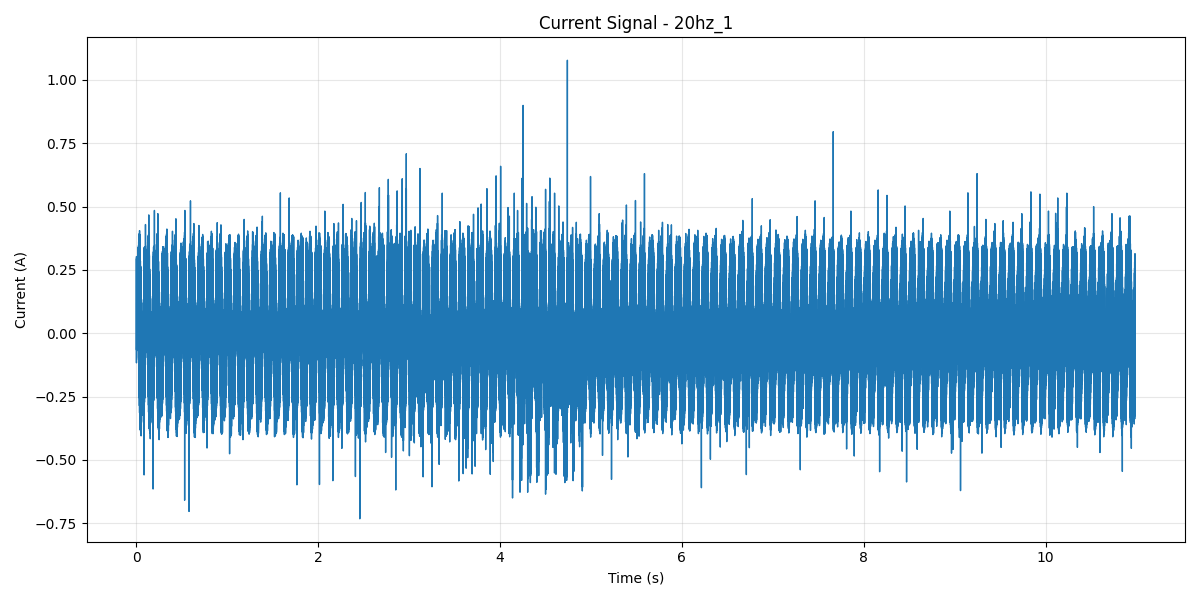

In [17]:
# Plot the time-domain signal
t = np.arange(len(file_data)) / fs

plt.figure(figsize=(12, 6))
plt.plot(t, file_data, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.title(f'Current Signal - {title}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

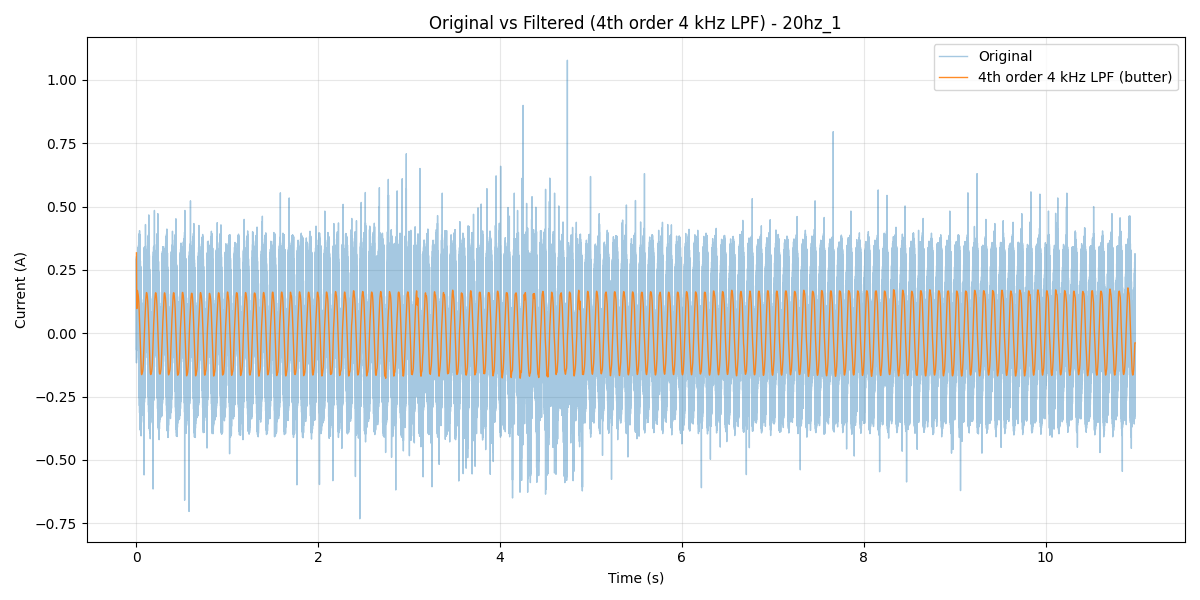

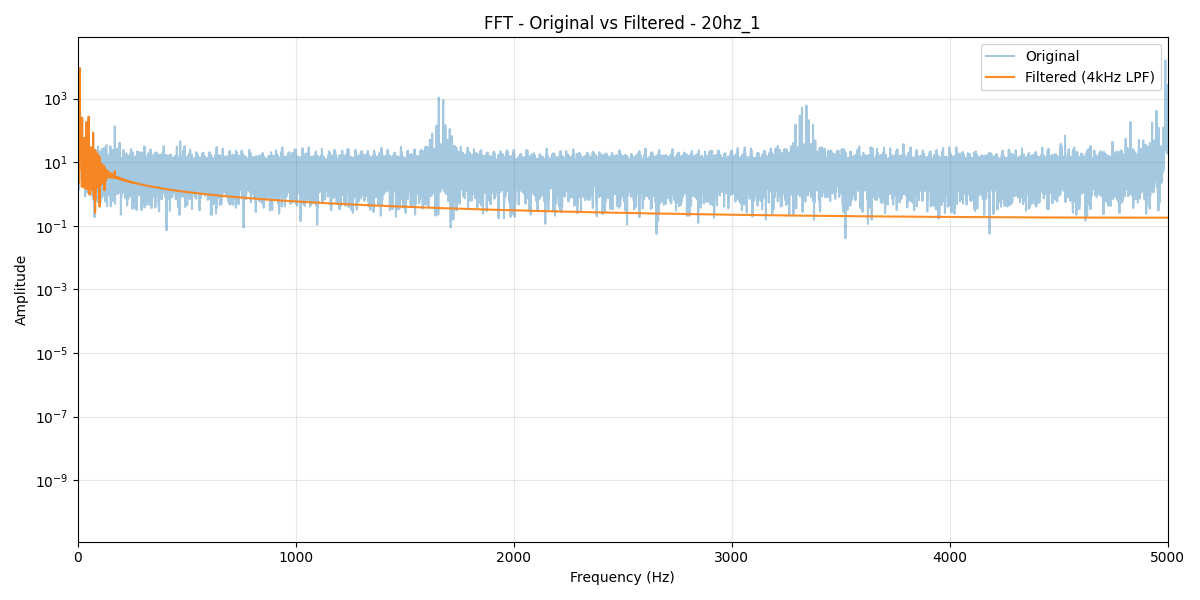

In [18]:
# Design and apply 4th order Butterworth low-pass filter at 4 kHz
from scipy.signal import butter, sosfiltfilt, sosfreqz

order = 4
fc = 100.0  # cutoff frequency in Hz
# Normalized cutoff frequency (Wn): 0..1 where 1 is Nyquist (fs/2)
Wn = fc / (fs / 2)
sos = butter(order, Wn, btype='low', output='sos')

# Apply zero-phase filtering to avoid phase distortion
file_data_filtered = sosfiltfilt(sos, file_data)

# Plot original and filtered signals (time domain)
t = np.arange(len(file_data)) / fs
plt.figure(figsize=(12, 6))
plt.plot(t, file_data, linewidth=1, alpha=0.4, label='Original')
plt.plot(t, file_data_filtered, linewidth=1, alpha=0.9, label='4th order 4 kHz LPF (butter)')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.title(f'Original vs Filtered (4th order 4 kHz LPF) - {title}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot frequency response and the amplitude spectra
n = len(file_data)
freqs = np.fft.rfftfreq(n, 1/fs)
orig_fft = np.abs(np.fft.rfft(file_data))
filt_fft = np.abs(np.fft.rfft(file_data_filtered))

plt.figure(figsize=(12, 6))
plt.semilogy(freqs, orig_fft, alpha=0.4, label='Original')
plt.semilogy(freqs, filt_fft, alpha=0.9, label='Filtered (4kHz LPF)')
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title(f'FFT - Original vs Filtered - {title}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()